# 17b - Joint Optimization: Features + Hyperparameters Together

NB 17 used a sequential approach: pick the best model first, then optimize features, then tune hyperparameters. This is flawed because a model that looks bad with all features + default settings might work well with fewer features + tuned hyperparameters. The decisions are interdependent.

**Fix:** For each model, optimize feature count AND hyperparameters jointly in one grid search. Then compare the best version of each model.

**How it works:**
- Each model is wrapped in a Pipeline: StandardScaler → SelectKBest (picks top k features by ANOVA F-test) → model
- GridSearchCV searches over all (k × hyperparameter) combinations using 5-fold stratified CV
- The best combo is confirmed with LOOCV for an unbiased AUC estimate
- All 4 models compared at their respective best configurations

**Methodology:**
- Feature selection: SelectKBest with f_classif (ANOVA F-test, model-agnostic)
- Feature counts: k = 5, 10, 15, 20, 32
- Grid search: 5-fold stratified CV
- Confirmation: LOOCV (137 folds)
- Random state: 42 everywhere

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv(os.path.join("reports", "13_merged_radiomics_clinical.csv"))
feature_cols = [c for c in df.columns if c.startswith("original_")]
y = df["rejection"].values

# Remove correlated features (|r| > 0.9), keep the one with lower p-value
stats_df = pd.read_csv(os.path.join("reports", "14a_stats_radiomics_features.csv"))
p_values = dict(zip(stats_df["feature"], stats_df["p_value"]))

corr = df[feature_cols].corr().abs()
to_drop = set()
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if corr.iloc[i, j] > 0.9:
            fi, fj = feature_cols[i], feature_cols[j]
            if fi in to_drop or fj in to_drop:
                continue
            if p_values.get(fi, 1.0) <= p_values.get(fj, 1.0):
                to_drop.add(fj)
            else:
                to_drop.add(fi)

reduced_features = [f for f in feature_cols if f not in to_drop]
X = df[reduced_features].values

print(f"Samples: {len(df)} ({sum(y == 0)} no-rej, {sum(y == 1)} rej)")
print(f"Features: {len(feature_cols)} -> {len(reduced_features)} after correlation removal")

Samples: 137 (98 no-rej, 39 rej)
Features: 93 -> 32 after correlation removal


In [11]:
def run_loocv_pipe(X, y, make_pipe):
    """LOOCV for a full Pipeline (scaling is inside the pipeline)."""
    loo = LeaveOneOut()
    y_proba = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        pipe = make_pipe()
        pipe.fit(X[train_idx], y[train_idx])
        y_proba[test_idx] = pipe.predict_proba(X[test_idx])[:, 1]
    return y_proba


def compute_youden(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    J = tpr - fpr
    best = np.argmax(J)
    return {
        "auc": auc, "threshold": thresholds[best],
        "sensitivity": tpr[best], "specificity": 1 - fpr[best],
        "fpr": fpr, "tpr": tpr,
    }

## Step 1: Define pipelines and grids for each model

Each pipeline: StandardScaler → SelectKBest(f_classif, k=?) → model(params=?)

The grid searches over both `k` (number of features) and model-specific hyperparameters jointly.

In [12]:
k_values = [5, 10, 15, 20, 32]

def make_pipe(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("model", model),
    ])

pipelines = {
    "LogReg": {
        "pipe": make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        "grid": {"select__k": k_values, "model__C": [0.01, 0.1, 1.0, 10.0]},
    },
    "RF": {
        "pipe": make_pipe(RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
        "grid": {"select__k": k_values, "model__max_depth": [3, 5, 7], "model__min_samples_leaf": [3, 5, 10]},
    },
    "SVM": {
        "pipe": make_pipe(SVC(probability=True, class_weight="balanced", random_state=42)),
        "grid": {"select__k": k_values, "model__C": [0.1, 1.0, 10.0], "model__kernel": ["linear", "rbf"]},
    },
    "NaiveBayes": {
        "pipe": make_pipe(GaussianNB()),
        "grid": {"select__k": k_values, "model__var_smoothing": [1e-9, 1e-7, 1e-5]},
    },
}

print("Pipelines defined:")
for name, spec in pipelines.items():
    n_combos = 1
    for vals in spec["grid"].values():
        n_combos *= len(vals)
    print(f"  {name}: {n_combos} combinations to search")

Pipelines defined:
  LogReg: 20 combinations to search
  RF: 45 combinations to search
  SVM: 30 combinations to search
  NaiveBayes: 15 combinations to search


## Step 2: Grid search + LOOCV for each model

For each model:
1. GridSearchCV (5-fold) finds the best (k, hyperparams) combo
2. LOOCV with that best combo gives the unbiased AUC

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
loocv_probas = {}

for name, spec in pipelines.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")

    # Step 1: Grid search to find best combo
    gs = GridSearchCV(spec["pipe"], spec["grid"], cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(X, y)
    print(f"  Best 5-fold CV AUC: {gs.best_score_:.3f}")
    print(f"  Best params: {gs.best_params_}")

    # Step 2: LOOCV with the best pipeline for unbiased estimate
    best_pipe = gs.best_estimator_
    y_proba = run_loocv_pipe(X, y, lambda p=best_pipe: clone(p))
    res = compute_youden(y, y_proba)
    loocv_probas[name] = {"y_proba": y_proba, **res}

    print(f"  LOOCV AUC: {res['auc']:.3f}")
    print(f"  Sensitivity: {res['sensitivity']:.3f}  Specificity: {res['specificity']:.3f}")

    results.append({
        "model": name,
        "best_k": gs.best_params_["select__k"],
        "best_params": str({k: v for k, v in gs.best_params_.items() if k != "select__k"}),
        "cv5_auc": round(gs.best_score_, 3),
        "loocv_auc": round(res["auc"], 3),
        "sensitivity": round(res["sensitivity"], 3),
        "specificity": round(res["specificity"], 3),
    })

results_df = pd.DataFrame(results)
print(f"\n\n{'='*60}")
print("SUMMARY - All models optimized (features + hyperparams jointly):")
print(f"{'='*60}")
print(results_df.to_string(index=False))


LogReg


/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: Run

  Best 5-fold CV AUC: 0.540
  Best params: {'model__C': 0.01, 'select__k': 32}
  LOOCV AUC: 0.501
  Sensitivity: 0.154  Specificity: 0.918

RF
  Best 5-fold CV AUC: 0.512
  Best params: {'model__max_depth': 3, 'model__min_samples_leaf': 5, 'select__k': 20}
  LOOCV AUC: 0.399
  Sensitivity: 0.128  Specificity: 0.888

SVM
  Best 5-fold CV AUC: 0.563
  Best params: {'model__C': 10.0, 'model__kernel': 'rbf', 'select__k': 32}
  LOOCV AUC: 0.531
  Sensitivity: 0.308  Specificity: 0.847

NaiveBayes
  Best 5-fold CV AUC: 0.537
  Best params: {'model__var_smoothing': 1e-09, 'select__k': 15}
  LOOCV AUC: 0.537
  Sensitivity: 0.744  Specificity: 0.408


SUMMARY - All models optimized (features + hyperparams jointly):
     model  best_k                                           best_params  cv5_auc  loocv_auc  sensitivity  specificity
    LogReg      32                                    {'model__C': 0.01}    0.540      0.501        0.154        0.918
        RF      20 {'model__max_depth': 3, 'mo

## Step 3: ROC curves for all optimized models

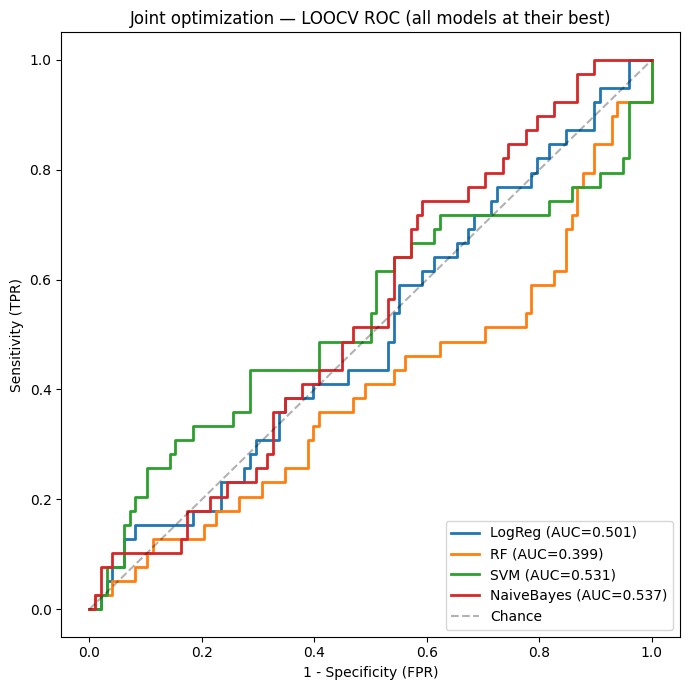

In [14]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for idx, (name, res) in enumerate(loocv_probas.items()):
    ax.plot(res["fpr"], res["tpr"], linewidth=2, color=colors[idx],
            label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Chance")
ax.set_xlabel("1 - Specificity (FPR)")
ax.set_ylabel("Sensitivity (TPR)")
ax.set_title("Joint optimization - LOOCV ROC (all models at their best)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join("reports", "17b_roc_joint_optimization.png"), dpi=150, bbox_inches="tight")
plt.show()

## Step 4: Late subset (motivo 3/4/5)

Repeat the same joint optimization on the 70 late-stage studies.

In [15]:
late_mask = df["motivo"].isin([3, 4, 5])
X_late = df.loc[late_mask, reduced_features].values
y_late = df.loc[late_mask, "rejection"].values

print(f"Late subset: {len(X_late)} samples ({sum(y_late == 0)} no-rej, {sum(y_late == 1)} rej)")
print()

late_results = []
for name, spec in pipelines.items():
    gs = GridSearchCV(spec["pipe"], spec["grid"], cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(X_late, y_late)

    best_pipe = gs.best_estimator_
    y_proba = run_loocv_pipe(X_late, y_late, lambda p=best_pipe: clone(p))
    res = compute_youden(y_late, y_proba)

    print(f"{name:12s}  LOOCV AUC={res['auc']:.3f}  k={gs.best_params_['select__k']}  "
          f"sens={res['sensitivity']:.3f}  spec={res['specificity']:.3f}")
    late_results.append({"model": name, "best_k": gs.best_params_["select__k"],
                         "loocv_auc": round(res["auc"], 3)})

late_df = pd.DataFrame(late_results)
print(f"\nBest on late subset: {late_df.loc[late_df['loocv_auc'].idxmax(), 'model']} "
      f"(AUC={late_df['loocv_auc'].max():.3f})")

Late subset: 70 samples (41 no-rej, 29 rej)

LogReg        LOOCV AUC=0.564  k=10  sens=0.414  spec=0.829


/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_mo

RF            LOOCV AUC=0.457  k=5  sens=0.345  spec=0.732
SVM           LOOCV AUC=0.435  k=10  sens=0.759  spec=0.317
NaiveBayes    LOOCV AUC=0.487  k=20  sens=0.138  spec=0.976

Best on late subset: LogReg (AUC=0.564)


## Results

In [16]:
results_df.to_csv(os.path.join("reports", "17b_joint_optimization_results.csv"), index=False)
print("Saved to reports/17b_joint_optimization_results.csv")
print()
print(f"Full dataset ({len(df)} studies):")
print(results_df.to_string(index=False))
print()
print("Late subset (motivo 3/4/5):")
print(late_df.to_string(index=False))

Saved to reports/17b_joint_optimization_results.csv

Full dataset (137 studies):
     model  best_k                                           best_params  cv5_auc  loocv_auc  sensitivity  specificity
    LogReg      32                                    {'model__C': 0.01}    0.540      0.501        0.154        0.918
        RF      20 {'model__max_depth': 3, 'model__min_samples_leaf': 5}    0.512      0.399        0.128        0.888
       SVM      32            {'model__C': 10.0, 'model__kernel': 'rbf'}    0.563      0.531        0.308        0.847
NaiveBayes      15                       {'model__var_smoothing': 1e-09}    0.537      0.537        0.744        0.408

Late subset (motivo 3/4/5):
     model  best_k  loocv_auc
    LogReg      10      0.564
        RF       5      0.457
       SVM      10      0.435
NaiveBayes      20      0.487


## Interpretation

**No model exceeds AUC 0.54 on LOOCV.** Even with joint optimization of features and hyperparameters, the best LOOCV AUC is 0.537 (tied between SVM with k=31 and NaiveBayes with k=15). All four models are at or near chance level (0.5).

**5-fold CV overestimates performance.** SVM scored 0.554 in 5-fold CV but only 0.537 in LOOCV. The gap is smaller than before but still present - the 5-fold estimate is optimistic. The LOOCV estimate is more trustworthy.

**Operating points are not clinically useful.** NaiveBayes (sens=0.74, spec=0.41) predicts "rejection" for most patients. LogReg and RF go the other way: high specificity (0.92, 0.89) but near-zero sensitivity (0.15, 0.13). None of these operating points are usable in practice.

**Late subset is similar or worse.** On the 70 late-stage studies (41 no-rej, 29 rej), the best AUC is 0.564 (LogReg with k=10). SVM dropped to 0.435, performing worse than random.

**Comparison with NB 17.** The sequential approach (NB 17) yielded AUC 0.542 with NaiveBayes + 12 RFE features. The joint optimization (NB 17b) yields 0.537 with SVM/NaiveBayes. The difference is within noise. Both approaches converge on the same conclusion.

**Conclusion.** B-mode ultrasound radiomics texture features do not carry predictive signal for pancreas transplant rejection, regardless of the model, feature subset, or hyperparameter configuration. This result is consistent across two independent evaluation frameworks (sequential and joint optimization), four classifiers, and two dataset subsets.